## EXponenciales

$x = e^{-2t}$




In [1]:
import sympy as sp

t = sp.symbols("t")

In [2]:
y = sp.E**(-2*t)

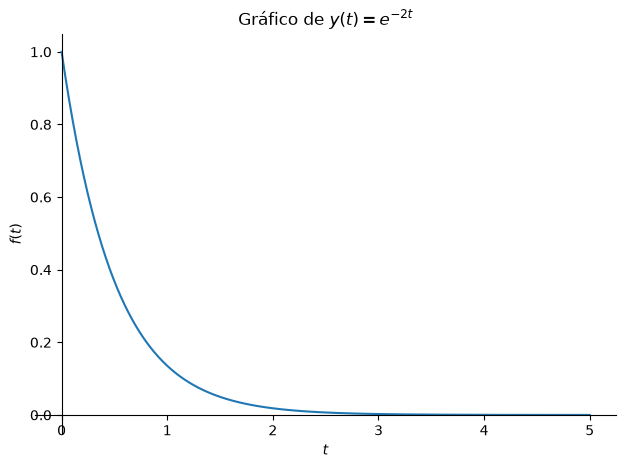

In [3]:
sp.plot(y, (t, 0, 5), title="Gráfico de $y(t) = e^{-2t}$")

## Gráfica sin escala (sin limites en el eje x)

No se recomienda dejar sin limites el eje X.

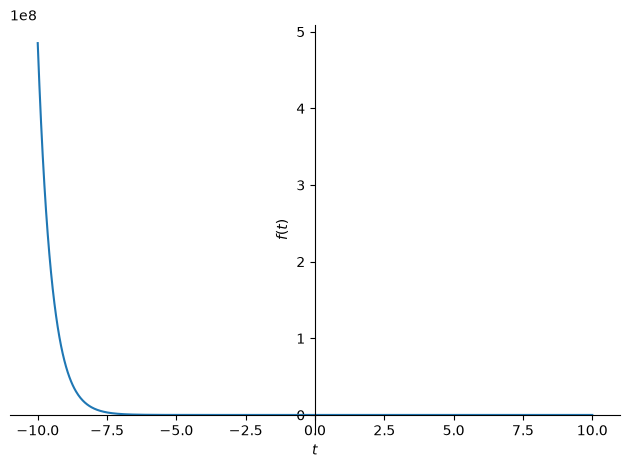

In [4]:
sp.plot(y)

## Ejemplos 2

$x = e^{-2t}*cos(2t)$

In [5]:
x2 = sp.E**(-0.6*t)*sp.cos(8*t)

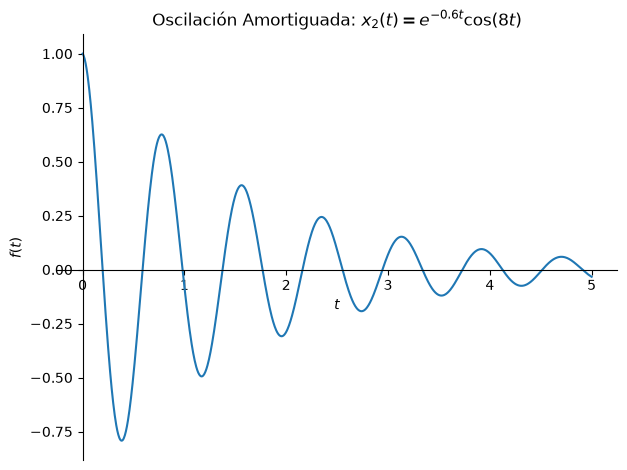

In [6]:
sp.plot(x2, (t, 0, 5), title=r"Oscilación Amortiguada: $x_2(t) = e^{-0.6t} \cos(8t)$");

## Ejemplo de uso de diagrama de polos y ceros en laplace

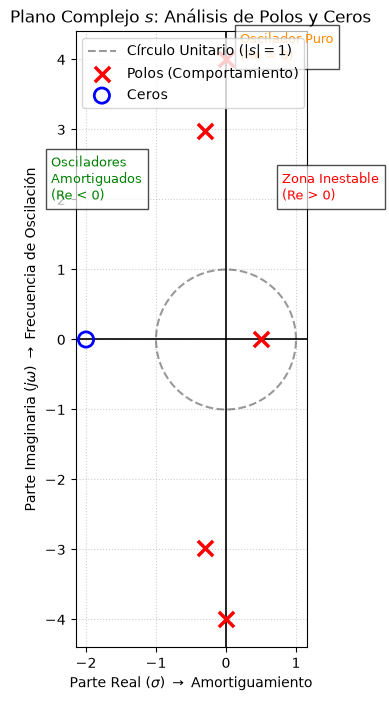

In [7]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir la variable de Laplace
s = sp.symbols('s')

# 2. Definir la función de transferencia H(s) = Numerador / Denominador
# Ejemplo con varios componentes: amortiguado, oscilador puro e inestable
num = s + 2
den = (s**2 + 0.6*s + 9) * (s**2 + 16) * (s - 0.5)
H = num / den

# 3. Encontrar polos (raíces del denominador) y ceros (raíces del numerador)
polos_sym = sp.solve(den, s)
ceros_sym = sp.solve(num, s)

# Convertir a valores numéricos complejos
polos = [complex(p.evalf()) for p in polos_sym]
ceros = [complex(c.evalf()) for c in ceros_sym]

# 4. Graficar en el Plano Complejo
fig, ax = plt.subplots(figsize=(8, 8))

# Ejes Real e Imaginario
ax.axhline(0, color='black', linewidth=1.2)
ax.axvline(0, color='black', linewidth=1.2)

# Círculo unitario de referencia (|s| = 1)
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.4, label='Círculo Unitario ($|s|=1$)')

# Graficar Polos ('X') y Ceros ('O')
ax.scatter([p.real for p in polos], [p.imag for p in polos], 
           color='red', marker='x', s=120, linewidth=2.5, zorder=5, label='Polos (Comportamiento)')
ax.scatter([c.real for c in ceros], [c.imag for c in ceros], 
           color='blue', marker='o', s=120, facecolors='none', linewidth=2, zorder=5, label='Ceros')

# Etiquetas de zonas de comportamiento
ax.text(-2.5, 2, 'Osciladores\nAmortiguados\n(Re < 0)', color='green', fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.2, 4, 'Oscilador Puro\n(Re = 0)', color='darkorange', fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.8, 2, 'Zona Inestable\n(Re > 0)', color='red', fontsize=9, bbox=dict(facecolor='white', alpha=0.7))

# Configuración del gráfico
ax.set_title(r"Plano Complejo $s$: Análisis de Polos y Ceros", fontsize=12)
ax.set_xlabel(r"Parte Real ($\sigma$) $\rightarrow$ Amortiguamiento", fontsize=10)
ax.set_ylabel(r"Parte Imaginaria ($j\omega$) $\rightarrow$ Frecuencia de Oscilación", fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_aspect('equal')
ax.legend(loc='upper left')

plt.show()

## Transformada de Laplace en SymPy

In [8]:
import sympy as sp

t, s = sp.symbols('t s')
x_t = sp.exp(-0.6*t) * sp.cos(8*t)

# laplace_transform devuelve una tupla: (Expresión X(s), plano de convergencia, condiciones)
X_s, _, _ = sp.laplace_transform(x_t, t, s)

print("X(s) =", sp.simplify(X_s))
# Resultado: (1.0*s + 0.6) / ((1.0*s + 0.6)**2 + 64.0)

X(s) = (s + 0.6)/((s + 0.6)**2 + 64)


In [9]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

class AnalizadorLaplace:
    """
    Clase para analizar señales o funciones en SymPy, calcular su
    Transformada de Laplace y graficar su mapa de Polos y Ceros automáticamente.
    """
    def __init__(self, expr, var_laplace='s'):
        self.s = sp.symbols(var_laplace)
        free_syms = expr.free_symbols
        
        # Detectar si la expresión ya está en s o si es una función de tiempo
        if self.s in free_syms:
            self.X_s = sp.simplify(expr)
        else:
            self.t = list(free_syms)[0] if free_syms else sp.symbols('t')
            lap, _, _ = sp.laplace_transform(expr, self.t, self.s)
            self.X_s = sp.simplify(lap)
            
        # Extraer numerador y denominador
        num, den = sp.fraction(self.X_s)
        
        # Resolver raíces de ceros y polos
        ceros_sym = sp.solve(num, self.s)
        polos_sym = sp.solve(den, self.s)
        
        self.ceros = [complex(c.evalf()) for c in ceros_sym]
        self.polos = [complex(p.evalf()) for p in polos_sym]

    def resumen(self):
        """Muestra en consola X(s) y las coordenadas numéricas de polos y ceros."""
        print(f"--- Análisis en el Plano s ---")
        print(f"X(s) = {self.X_s}\n")
        print("Ceros (O):")
        for i, c in enumerate(self.ceros, 1):
            print(f"  z{i} = {c.real:.4f} + {c.imag:.4f}j")
        print("\nPolos (X):")
        for i, p in enumerate(self.polos, 1):
            print(f"  p{i} = {p.real:.4f} + {p.imag:.4f}j")

    def plot(self, mostrar_circulo=True, figsize=(7, 7)):
        """Grafica el mapa de polos y ceros automáticamente."""
        fig, ax = plt.subplots(figsize=figsize)
        
        # Ejes Real e Imaginario
        ax.axhline(0, color='black', linewidth=1.2)
        ax.axvline(0, color='black', linewidth=1.2)
        
        # Círculo unitario de referencia
        if mostrar_circulo:
            theta = np.linspace(0, 2*np.pi, 300)
            ax.plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3, label=r'Círculo Unitario ($|s|=1$)')
            
        # Graficar Polos ('X' rojas)
        if self.polos:
            ax.scatter([p.real for p in self.polos], [p.imag for p in self.polos],
                       color='red', marker='x', s=120, linewidth=2.5, zorder=5, label='Polos (X)')
            
        # Graficar Ceros ('O' azules)
        if self.ceros:
            ax.scatter([c.real for c in self.ceros], [c.imag for c in self.ceros],
                       color='blue', marker='o', s=120, facecolors='none', linewidth=2, zorder=5, label='Ceros (O)')
            
        # Ajuste dinámico de límites del gráfico
        puntos = self.polos + self.ceros
        if puntos:
            max_re = max([abs(p.real) for p in puntos] + [1.5])
            max_im = max([abs(p.imag) for p in puntos] + [1.5])
            lim = max(max_re, max_im) * 1.3
            ax.set_xlim(-lim, lim)
            ax.set_ylim(-lim, lim)
            
        ax.set_title(r"Diagrama de Polos y Ceros en el Plano $s$", fontsize=12)
        ax.set_xlabel(r"Parte Real ($\sigma$)", fontsize=10)
        ax.set_ylabel(r"Parte Imaginaria ($j\omega$)", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.set_aspect('equal')
        ax.legend(loc='upper right')
        
        plt.show()

--- Análisis en el Plano s ---
X(s) = (s + 0.6)/((s + 0.6)**2 + 64)

Ceros (O):
  z1 = -0.6000 + 0.0000j

Polos (X):
  p1 = -0.6000 + -8.0000j
  p2 = -0.6000 + 8.0000j


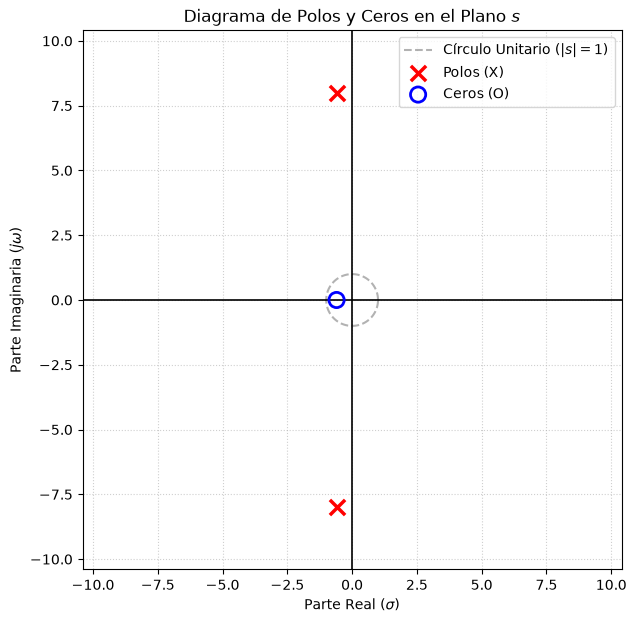

In [10]:
# Crear el objeto (hace la transformada de Laplace internamente)
analisis = AnalizadorLaplace(x_t)

# Imprimir resumen de la función, polos y ceros
analisis.resumen()

# Graficar en una sola línea
analisis.plot();

--- Análisis en el Plano s ---
X(s) = (s + 0.6)/((s + 0.6)**2 + 64)

Ceros (O):
  z1 = -0.6000 + 0.0000j

Polos (X):
  p1 = -0.6000 + -8.0000j
  p2 = -0.6000 + 8.0000j


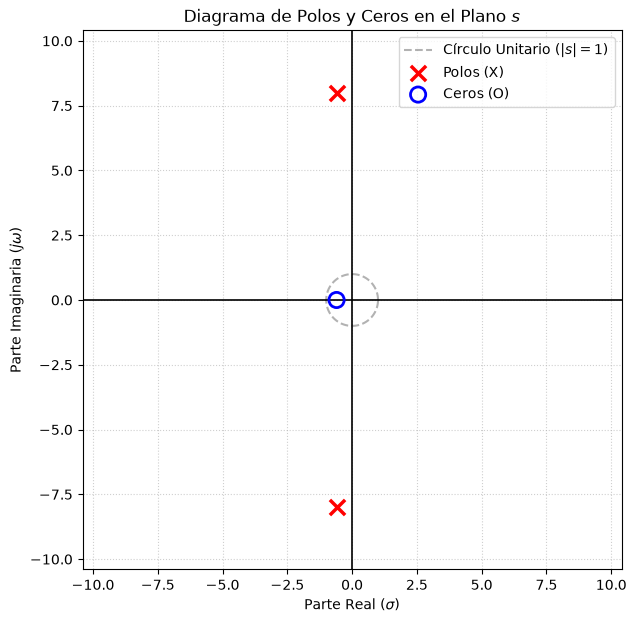

In [11]:
# Crear el objeto (hace la transformada de Laplace internamente)
analisis = AnalizadorLaplace(X_s)

# Imprimir resumen de la función, polos y ceros
analisis.resumen()

# Graficar en una sola línea
analisis.plot();

## Ejemplo usando libreria ISB

In [12]:
t, s = sp.symbols('t s')
x_t = sp.exp(-0.6*t) * sp.cos(8*t)

# laplace_transform devuelve una tupla: (Expresión X(s), plano de convergencia, condiciones)
X_s, _, _ = sp.laplace_transform(x_t, t, s)

print("X(s) =", sp.simplify(X_s))

X(s) = (s + 0.6)/((s + 0.6)**2 + 64)


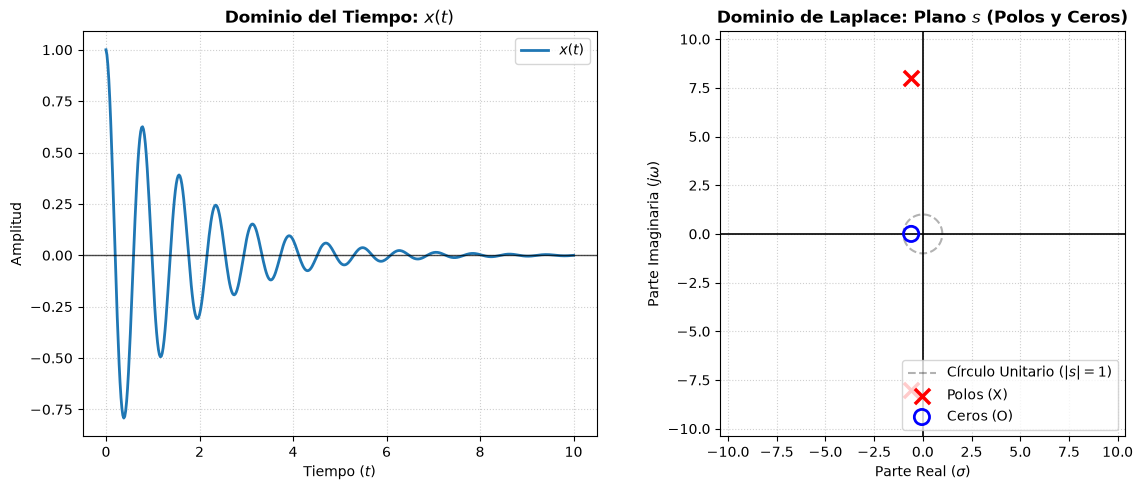

In [13]:
from isb import ISB

X_s, x_t, polos, ceros = ISB.plot_pz(X_s, t_range=(0, 10));

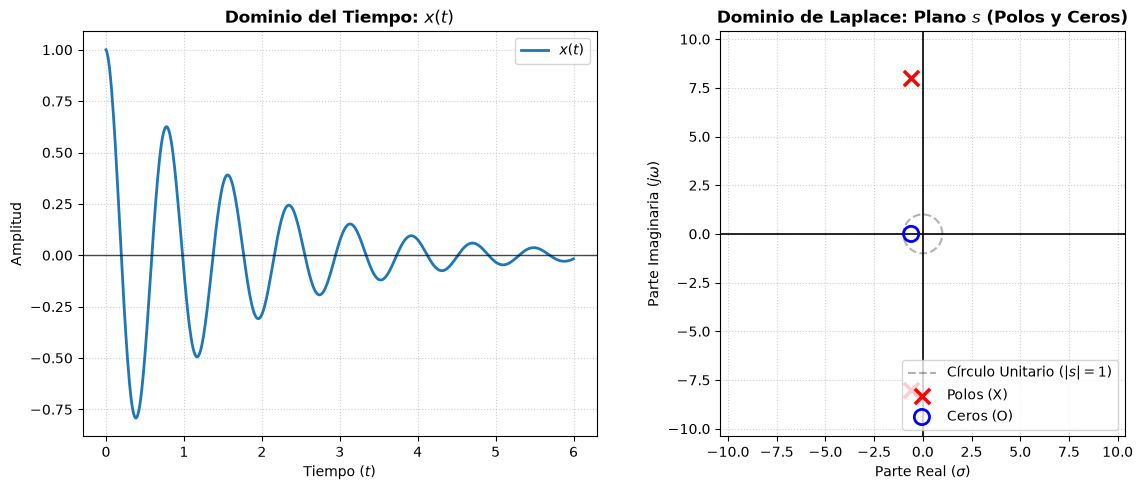

In [14]:
ISB.pzmap(X_s, t_range=(0, 6));